# Supervised Learning Model Evaluation Lab

Complete the exercises below to solidify your knowledge and understanding of supervised learning model evaluation.

In [17]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## Regression Model Evaluation

In [18]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
data = pd.read_csv('housing.csv', header=None, delimiter=r"\s+", names=column_names)

In [19]:
"""
CRIM - per capita crime rate by town
ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS - proportion of non-retail business acres per town.
CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
NOX - nitric oxides concentration (parts per 10 million)
RM - average number of rooms per dwelling
AGE - proportion of owner-occupied units built prior to 1940
DIS - weighted distances to five Boston employment centres
RAD - index of accessibility to radial highways
TAX - full-value property-tax rate per $10,000
PTRATIO - pupil-teacher ratio by town
B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
LSTAT - % lower status of the population
MEDV - Median value of owner-occupied homes in $1000's"""

"\nCRIM - per capita crime rate by town\nZN - proportion of residential land zoned for lots over 25,000 sq.ft.\nINDUS - proportion of non-retail business acres per town.\nCHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)\nNOX - nitric oxides concentration (parts per 10 million)\nRM - average number of rooms per dwelling\nAGE - proportion of owner-occupied units built prior to 1940\nDIS - weighted distances to five Boston employment centres\nRAD - index of accessibility to radial highways\nTAX - full-value property-tax rate per $10,000\nPTRATIO - pupil-teacher ratio by town\nB - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town\nLSTAT - % lower status of the population\nMEDV - Median value of owner-occupied homes in $1000's"

In [20]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


## 1. Split this data set into training (80%) and testing (20%) sets.

The `MEDV` field represents the median value of owner-occupied homes (in $1000's) and is the target variable that we will want to predict.

In [21]:
from sklearn.model_selection import train_test_split

X = data.drop('MEDV', axis=1)
y = data['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print(f"All data: {data.shape[0]}")
print(f"Training set size: {X_train.shape[0]}" )
print(f"Testing set size: {y_test.shape[0]}")

All data: 506
Training set size: 404
Testing set size: 102


## 2. Train a `LinearRegression` model on this data set and generate predictions on both the training and the testing set.

In [22]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
train_predictions = lr.predict(X_train)
test_predictions = lr.predict(X_test)

print(f"Testing predictions: {test_predictions[:5]}")
print(f"Real values: {y_test[:5].values}")

Testing predictions: [28.99672362 36.02556534 14.81694405 25.03197915 18.76987992]
Real values: [23.6 32.4 13.6 22.8 16.1]


## 3. Calculate and print R-squared for both the training and the testing set.

In [23]:
from sklearn.metrics import r2_score
r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)

print(f"R² score (training set): {r2_train:.3f}")
print(f"R² score (testing set): {r2_test:.3f}")

R² score (training set): 0.751
R² score (testing set): 0.669


## 4. Calculate and print mean squared error for both the training and the testing set.

In [24]:
from sklearn.metrics import mean_squared_error
mse_train = mean_squared_error(y_train, train_predictions)
mse_test = mean_squared_error(y_test, test_predictions)
print(f"Mean Squared Error (training set): {mse_train:.3f}")
print(f"Mean Squared Error (testing set): {mse_test:.3f}")

Mean Squared Error (training set): 21.641
Mean Squared Error (testing set): 24.291


## 5. Calculate and print mean absolute error for both the training and the testing set.

In [25]:
from sklearn.metrics import mean_absolute_error
mae_train = mean_absolute_error(y_train, train_predictions)
mae_test = mean_absolute_error(y_test, test_predictions)
print(f"Mean Absolute Error (training set): {mae_train:.3f}")
print(f"Mean Absolute Error (testing set): {mae_test:.3f}")

Mean Absolute Error (training set): 3.315
Mean Absolute Error (testing set): 3.189


## Classification Model Evaluation

In [26]:
from sklearn.datasets import load_iris
data = load_iris()

In [27]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [43]:
column_names = data.feature_names

In [45]:
df = pd.DataFrame(data['data'],columns=column_names)

In [46]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [47]:
target = pd.DataFrame(data.target)

In [32]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [48]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## 6. Split this data set into training (80%) and testing (20%) sets.

The `class` field represents the type of flower and is the target variable that we will want to predict.

In [ ]:
from sklearn.model_selection import train_test_split
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"All flowers: {len(X)}")
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

All flowers: 150
Training set size: 120
Testing set size: 30


## 7. Train a `LogisticRegression` model on this data set and generate predictions on both the training and the testing set.

In [50]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)
print(f"Predicted classes: {y_pred}")
print(f"Real classes: {y_test}")

Predicted classes: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Real classes: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


## 8. Calculate and print the accuracy score for both the training and the testing set.

In [51]:
from sklearn.metrics import accuracy_score

train_predictions = logreg.predict(X_train)
test_predictions = logreg.predict(X_test)
accuracy_train = accuracy_score(y_train, train_predictions)
accuracy_test = accuracy_score(y_test, test_predictions)
print(f"Accuracy (training set): {accuracy_train:.3f}")
print(f"Accuracy (testing set): {accuracy_test:.3f}")

Accuracy (training set): 0.975
Accuracy (testing set): 1.000


## 9. Calculate and print the balanced accuracy score for both the training and the testing set.

In [52]:
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_train = balanced_accuracy_score(y_train, train_predictions)
balanced_accuracy_test = balanced_accuracy_score(y_test, test_predictions)
print(f"Balanced Accuracy (training set): {balanced_accuracy_train:.3f}")
print(f"Balanced Accuracy (testing set): {balanced_accuracy_test:.3f}")

Balanced Accuracy (training set): 0.976
Balanced Accuracy (testing set): 1.000


## 10. Calculate and print the precision score for both the training and the testing set.

In [53]:
from sklearn.metrics import precision_score
precision_train = precision_score(y_train, train_predictions, average='weighted')
precision_test = precision_score(y_test, test_predictions, average='weighted')
print(f"Precision (training set): {precision_train:.3f}")
print(f"Precision (testing set): {precision_test:.3f}")

Precision (training set): 0.977
Precision (testing set): 1.000


## 11. Calculate and print the recall score for both the training and the testing set.

In [ ]:
from sklearn.metrics import recall_score

recall_train = recall_score(y_train, train_predictions, average='weighted')
recall_test = recall_score(y_test, test_predictions, average='weighted')

print(f"Recall (Training set): {recall_train:.4f}")
print(f"Recall (Testing set):  {recall_test:.4f}")

Recall (Training set): 0.9750
Recall (Testing set):  1.0000


## 12. Calculate and print the F1 score for both the training and the testing set.

In [55]:
from sklearn.metrics import f1_score
f1_train = f1_score(y_train, train_predictions, average='weighted')
f1_test = f1_score(y_test, test_predictions, average='weighted')
print(f"F1 Score (Training set): {f1_train:.4f}")
print(f"F1 Score (Testing set):  {f1_test:.4f}")

F1 Score (Training set): 0.9750
F1 Score (Testing set):  1.0000


## 13. Generate confusion matrices for both the training and the testing set.

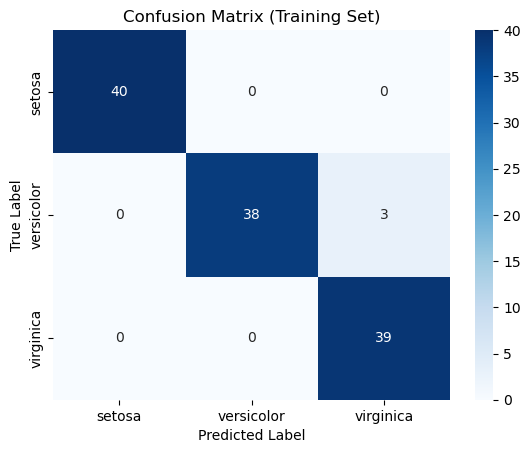

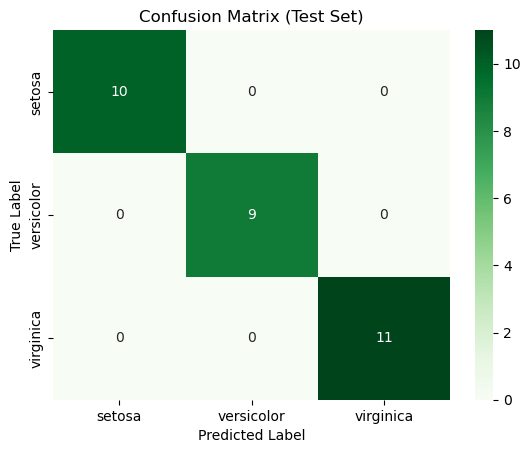

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm_train = confusion_matrix(y_train, train_predictions)
cm_test = confusion_matrix(y_test, test_predictions)
sns.heatmap(cm_train, annot=True, fmt='d',cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title("Confusion Matrix (Training Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("confusion_matrix_train.png")
plt.show()
sns.heatmap(cm_test, annot=True, fmt='d',cmap='Greens', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("confusion_matrix_test.png")
plt.show()


## Bonus: For each of the data sets in this lab, try training with some of the other models you have learned about, recalculate the evaluation metrics, and compare to determine which models perform best on each data set.

In [42]:
# Have fun here !